In [13]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('Data/train.csv')

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Categorical Data


### a.Countplot

<Axes: xlabel='Embarked', ylabel='count'>

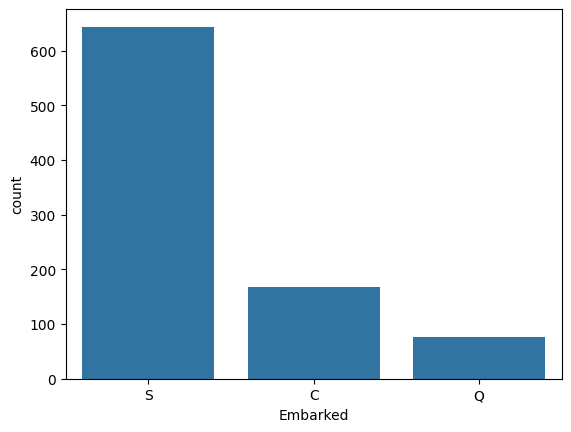

In [25]:
sns.countplot(x='Embarked', data=df)
# df['Survived'].value_counts()

### b. Pie Chart

<Axes: ylabel='count'>

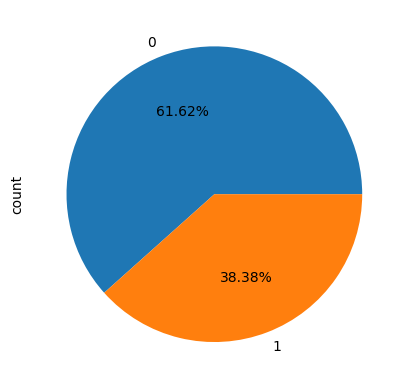

In [27]:
 df['Survived'].value_counts().plot(kind='pie', autopct='%.2f%%')

## 2. Numerical Data


### a. Histogram

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

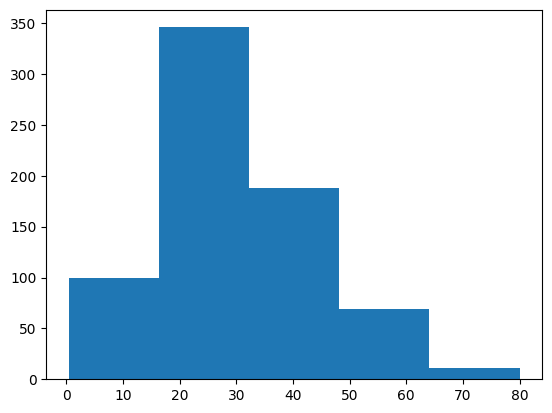

In [32]:
plt.hist(df['Age'], bins=5)

<Axes: xlabel='Age', ylabel='Density'>

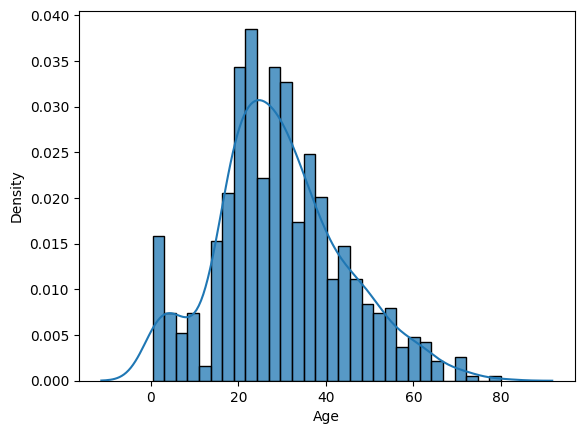

In [34]:
sns.histplot(df['Age'], bins=30, stat="density")
sns.kdeplot(df['Age'])


<Axes: xlabel='Age'>

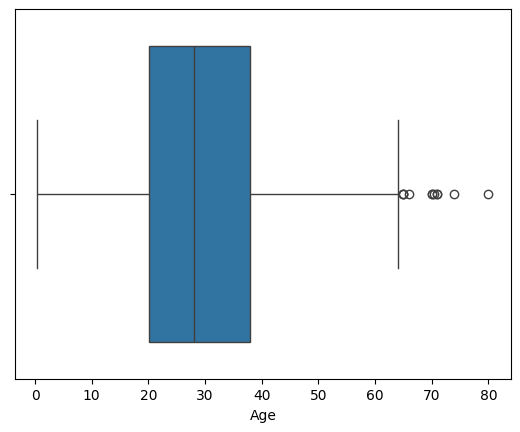

In [37]:
sns.boxplot(x=df['Age'])

In [38]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:


def detect_outliers_sd(data, threshold=3):
    """
    Detect outliers using Standard Deviation method (Z-score)
    
    Parameters:
    -----------
    data : array-like
        The dataset
    threshold : float
        Z-score threshold (default: 3)
    
    Returns:
    --------
    outliers : array
        Array of outliers
    outlier_indices : array
        Indices of outliers
    """
    # Calculate z-scores
    z_scores = np.abs(stats.zscore(data))
    
    # Identify outliers
    outlier_indices = np.where(z_scores > threshold)[0]
    outliers = data[outlier_indices]
    
    return outliers, outlier_indices

# Example with our website load times
data = np.array([1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 100.0])
mean = np.mean(data)
sd = np.std(data, ddof=1)  # Sample standard deviation

print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {sd:.2f}")

# Calculate z-scores manually
print("\nZ-scores calculation:")
for i, value in enumerate(data):
    z_score = (value - mean) / sd
    print(f"{value}: z = {z_score:.2f}")
    
# Detect outliers
outliers, indices = detect_outliers_sd(data, threshold=3)
print(f"\nOutliers detected (z > 3): {outliers}")
print(f"Outlier indices: {indices}")

Mean: 11.44
Standard Deviation: 31.12

Z-scores calculation:
1.2: z = -0.33
1.3: z = -0.33
1.4: z = -0.32
1.5: z = -0.32
1.6: z = -0.32
1.7: z = -0.31
1.8: z = -0.31
1.9: z = -0.31
2.0: z = -0.30
100.0: z = 2.85

Outliers detected (z > 3): []
Outlier indices: []
